# Decision Tree From Scratch

Implemented using **NumPy** — `sklearn` is only used to load the Iris dataset.

In this notebook we implement a **Decision Tree classifier from scratch**, covering:
- The **Node** class — the building block of every tree
- **Entropy** — measuring impurity in a set of labels
- **Information Gain** — choosing the best feature and threshold to split on
- **Tree Building** — recursively growing the tree
- A clean, reusable `DecisionTree` class with `fit`, `predict`, and `print_tree`
- Our own **`train_test_split`** — no sklearn utilities

Resources that helped me build this:

Video — Intuition & Implementation: https://youtu.be/ZVR2Way4nwQ?si=NsTQPGkC7oRoFgFH

StatQuest — Decision Trees: https://youtu.be/7VeUPuFGJHk?si=0hHTXqBz8Xh_m5El

## What is a Decision Tree?

A **Decision Tree** is a non-linear classifier that learns a hierarchy of **if-else rules** directly from data.

At each internal **decision node**, the tree asks a question about one feature:
▶ *"is the length ≤ 8?"*

Samples are routed left `yes` or right `no`. This repeats recursively until we reach a **leaf node**, which holds a class label — the tree's prediction.

The key question is: **which feature and threshold should we split on?**

We answer this using **Information Gain** — we pick the split that reduces uncertainty (entropy) the most.

Unlike Linear and Logistic Regression, Decision Trees can capture **non-linear** decision boundaries made of axis-aligned rectangles.

Let's start coding 🤓.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_iris  # just to load Iris

## 2. Load & Explore Data

We use the classic **Iris dataset** — 150 samples, 4 features, 3 classes:
- `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`
- Classes: `Iris-setosa`, `Iris-versicolor`, `Iris-virginica`

We load it straight from sklearn (no CSV file needed) and keep everything as NumPy arrays from here on.

In [2]:
iris = load_iris()

X = iris.data  # shape (150, 4)
y = iris.target_names[iris.target]

FEATURE_NAMES = iris.feature_names

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {iris.target_names}")
print(f"Features      : {FEATURE_NAMES}")
print(f"\nFirst 5 rows:")
print(X[:5])

Dataset shape : (150, 4)
Classes       : ['setosa' 'versicolor' 'virginica']
Features      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 3. Visualize the Data

Before building anything, let's look at the data.

We plot the two most informative features — **petal length** and **petal width** — which are already
nearly linearly separable. Our tree will learn to cut this space with horizontal and vertical lines.

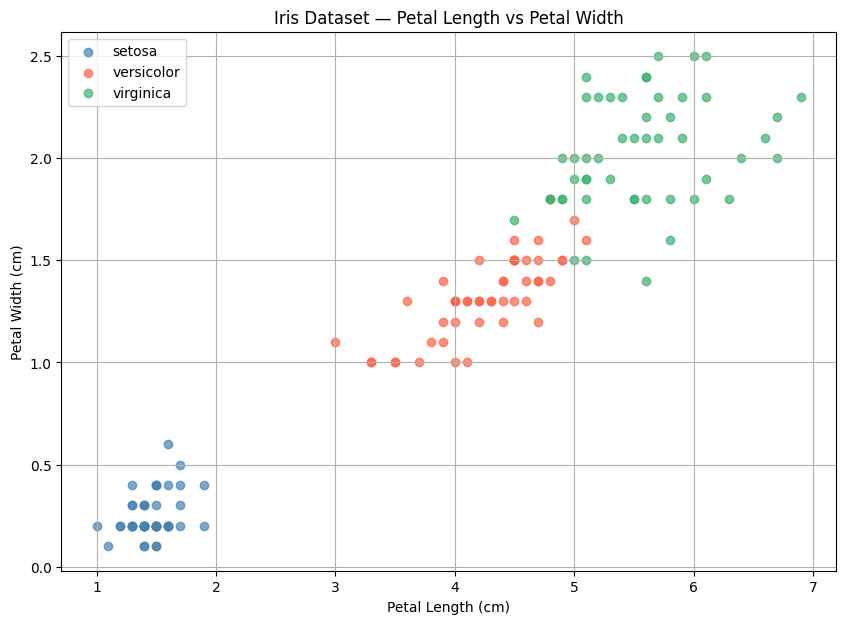

In [3]:
colors = {
    "setosa": "steelblue",
    "versicolor": "tomato",
    "virginica": "mediumseagreen"
}

plt.figure(figsize=(10, 7))

for label in iris.target_names:
    mask = (y == label)
    plt.scatter(
        X[mask, 2],
        X[mask, 3],
        color=colors[label],
        label=label,
        alpha=0.7
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset — Petal Length vs Petal Width")
plt.legend()
plt.grid(True)
plt.show()

## 4. Train / Test Split — From Scratch

We write our own `train_test_split` using NumPy's random permutation.

The idea is simple:
1. Shuffle the indices randomly
2. Slice the first `(1 - test_size) * m` indices → training set
3. Slice the rest → test set

In [4]:
def train_test_split(X, y, test_size=0.2, random_state=None):
  """
  Radnomly split X and y into train and test sets .

  test_size : float, default=0.2
  random_seed : for reproducibility
  """

  if random_state is not None:
    np.random.seed(random_state)

  m = len(y)
  indices = np.random.permutation(m)

  split = int(m * (1 - test_size))
  train_idx, test_idx = indices[:split], indices[split:]

  return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")


X_train shape : (120, 4)
y_train shape : (120,)


## 5. Entropy — Measuring Impurity

**Entropy** measures how mixed (impure) a set of labels is:

$$H(y) = -\sum_{c} p_c \log_2(p_c)$$

where $p_c$ is the fraction of samples belonging to class $c$.

- **Entropy = 0** → perfectly pure (all samples are the same class)
- **Entropy is maximized** → samples are equally split across all classes

We implement this in fully vectorized NumPy — no loop over class labels.

In [5]:
def entropy(y):
  """
  compute entropy of a label array.
  """

  if len(y) == 0:
    return 0

  _,counts = np.unique(y, return_counts=True)
  p = counts / len(y)

  return -np.sum(p * np.log2(p + 1e-12)) # garding for log(0)

## 6. Information Gain — Choosing the Best Split

**Information Gain** measures how much a split reduces entropy:

$$IG = H(\text{parent}) - \left( \frac{|L|}{|P|} \cdot H(L) + \frac{|R|}{|P|} \cdot H(R) \right)$$

where:
- $H(\text{parent})$ → entropy before the split
- $H(L)$, $H(R)$ → entropy of the left and right child sets
- $|L|$, $|R|$, $|P|$ → number of samples in left, right, and parent

We want to find the feature and threshold that **maximizes** Information Gain.

In [6]:
def information_gain(parent, left, right):
  """
  Info gainer of splitting parent into left and right
  """
  left_weight = len(left) / len(parent)
  right_weight = len(right) / len(parent)

  return entropy(parent) - (left_weight * entropy(left) + right_weight * entropy(right))

## 7. The Node Class

Every tree is made of **nodes**. A node is one of two things:

- **Decision node** — stores a split rule: *feature index*, *threshold*, and pointers to *left* and *right* children
- **Leaf node** — stores a class *value* (the majority class of samples that reached it)

A node is a leaf when `value is not None`.

In [7]:
class Node:
  def __init__(self,
               feature_idx=None,
               threshold=None,
               information_gain=None,
               left=None,
               right=None,
               value=None):
    self.feature_idx = feature_idx
    self.threshold = threshold
    self.information_gain = information_gain
    self.left = left
    self.right = right

    #leaf node attrebute
    self.value = value
  @property
  def is_leaf(self):
    return self.value is not None

## 8. The DecisionTree Class

Now we put everything together.

**`fit`** builds the tree by calling `build_tree` recursively:
1. If stopping conditions are met (too few samples or max depth reached), create a **leaf node** with the majority class
2. Otherwise, find the **best split** — the feature + threshold with the highest Information Gain
3. Split the dataset and recurse on left and right subsets

**`split`** divides a dataset into two subsets using vectorized boolean masking — no list comprehension.

**`best_split`** loops over every feature and every unique threshold value, evaluating Information Gain for each candidate split.

**`predict`** traverses the tree recursively for each sample.

**`print_tree`** prints a human-readable ASCII representation of the learned rules, using actual feature names.

In [8]:
class DecisionTree:
  def __init__(self,
               min_samples_split=2,
               max_depth=2):
    self.max_depth = max_depth
    self.min_samples_split = min_samples_split
    self.root = None

  #-- splitting -------------------------------
  def split(self, dataset, feature_idx, threshold):
    """
    split dataset into left and right subsets based on the threshold.
    using vectorized boolean masking
    """
    mask = dataset[:, feature_idx] <= threshold
    return dataset[mask], dataset[~mask]

  def best_split(self, dataset, n_features):
    """
    exhaustive search :find the feature + threshold with the highest IG.
    """

    best = {
        "feature_idx" : None,
        "threshold" : None,
        "information_gain" : -1,
        "left" : None,
        "right" : None
    }

    for feature_idx in range(n_features):
      thresholds = np.unique(dataset[:, feature_idx])

      for threshold in thresholds:
        left, right = self.split(dataset, feature_idx, threshold)

        if len(left) == 0  or len(right) == 0:
          continue
        ig = information_gain(dataset[:, -1], left[:, -1], right[:, -1])

        if ig > best["information_gain"]:
          best["feature_idx"] = feature_idx
          best["threshold"] = threshold
          best["information_gain"] = ig
          best["left"] = left
          best["right"] = right

    return best

  # --Tree build ------------------------
  def build_tree(self, dataset, curr_depth=0):
    X, y = dataset[:, :-1], dataset[:, -1]   # ← unpack here, not outside
    n_samples, n_features = X.shape           # ← now X exists

    if n_samples < self.min_samples_split or curr_depth >= self.max_depth:
        leaf_value = Counter(y).most_common(1)[0][0]  # ← y exists
        return Node(value=leaf_value)

    best = self.best_split(dataset, n_features)  # ← dataset, not X y

    if best["information_gain"] <= 0:
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    left_node  = self.build_tree(best["left"],  curr_depth + 1)  # ← "left" not "left_X"
    right_node = self.build_tree(best["right"], curr_depth + 1)  # ← "right" not "right_y"
    return Node(
        feature_idx=best["feature_idx"],
        threshold=best["threshold"],
        information_gain=best["information_gain"],
        left=left_node,
        right=right_node
    )

  #--- Public API -------------------------
  def fit(self, X, y):
    """
    train the tree on features X and labels y.
    """
    dataset = np.concatenate([X, y.reshape(-1, 1)], axis=1)
    self.root = self.build_tree(dataset)
    return self

  def predict(self, X):
    """
    predict class labels for samples in X.
    """
    return np.array([self._traverse(row, self.root) for row in X])

  def _traverse(self, row, node):
    """
    recursively traverse the tree to make predictions.
    """
    if node.is_leaf:
      return node.value
    if row[node.feature_idx] <= float(node.threshold):
      return self._traverse(row, node.left)
    return self._traverse(row, node.right)
  #---- inspection -------------------------------------------

  def print_tree(self, node=None, depth=0, indent="|   ", feature_names=None):
    """
    print a human-readable ASCII representation of the learned rules.
    """
    if node is None:
      node = self.root

    prefix = indent * depth

    if node.is_leaf:
      print(f"{prefix}|-----class: {node.value}")
      return

    fname = feature_names[node.feature_idx] if feature_names else f"Feature {node.feature_idx}"
    print(f"{prefix}|--- {fname} <= {float(node.threshold):.2f}  (IG: {node.information_gain:.4f})")
    self.print_tree(node.left,  depth + 1, indent, feature_names)

    print(f"{prefix}|--- {fname} >  {float(node.threshold):.2f}")
    self.print_tree(node.right, depth + 1, indent, feature_names)

## 9. Train & Evaluate

We train the tree and check:
1. **Test accuracy** — how well does it generalize to unseen data?
2. **The tree structure** — what rules did it actually learn?

In [9]:
model = DecisionTree(min_samples_split=2, max_depth=3)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy    = np.mean(predictions == y_test) * 100
print(f"Test accuracy: {accuracy:.2f}%")

print("\n")
model.print_tree(feature_names=FEATURE_NAMES)

Test accuracy: 96.67%


|--- petal length (cm) <= 1.90  (IG: 0.9413)
|   |-----class: setosa
|--- petal length (cm) >  1.90
|   |--- petal width (cm) <= 1.70  (IG: 0.7132)
|   |   |--- petal length (cm) <= 4.90  (IG: 0.2592)
|   |   |   |-----class: versicolor
|   |   |--- petal length (cm) >  4.90
|   |   |   |-----class: virginica
|   |--- petal width (cm) >  1.70
|   |   |--- petal length (cm) <= 4.80  (IG: 0.1066)
|   |   |   |-----class: virginica
|   |   |--- petal length (cm) >  4.80
|   |   |   |-----class: virginica


## 10. Visualize the Decision Boundary

One of the most satisfying things about Decision Trees is what their boundaries look like:
**axis-aligned rectangles** — because every split is on a single feature at a fixed threshold.

We plot the decision boundary over a 2D slice of the feature space (petal length × petal width),
coloring each region by the class the tree assigns to it.

Compare this to the diagonal line from Logistic Regression — same task, completely different shape.

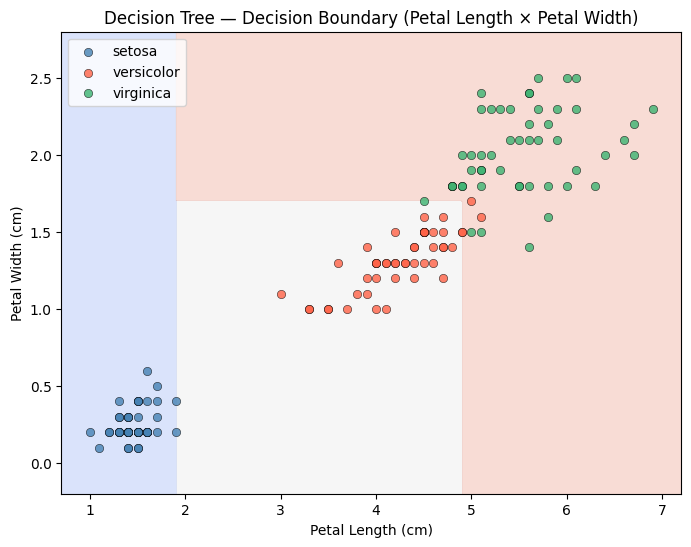

In [10]:
# We visualize on features 2 and 3 (petal length, petal width) — the most informative pair.
# To feed the full 4-feature model, we fix features 0 and 1 at their training-set means.

f0_mean = X_train[:, 0].mean()
f1_mean = X_train[:, 1].mean()

x2_min, x2_max = X[:, 2].min() - 0.3, X[:, 2].max() + 0.3
x3_min, x3_max = X[:, 3].min() - 0.3, X[:, 3].max() + 0.3

xx2, xx3 = np.meshgrid(
    np.linspace(x2_min, x2_max, 300),
    np.linspace(x3_min, x3_max, 300),
)

# Build full 4-feature grid
grid = np.column_stack([
    np.full(xx2.ravel().shape, f0_mean),
    np.full(xx2.ravel().shape, f1_mean),
    xx2.ravel(),
    xx3.ravel(),
])

label_to_int = {"setosa": 0, "versicolor": 1, "virginica": 2}
Z = np.array([label_to_int[p] for p in model.predict(grid)]).reshape(xx2.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx2, xx3, Z, alpha=0.25, cmap="coolwarm", levels=[-0.5, 0.5, 1.5, 2.5])

for label, color in colors.items():
    mask = (y == label)
    plt.scatter(X[mask, 2], X[mask, 3], label=label, color=color, alpha=0.8, edgecolors="k", linewidths=0.4)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Tree — Decision Boundary (Petal Length × Petal Width)")
plt.legend()
plt.show()